In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
from math import *

In [2]:
# Argument : the folder path 
# Return : an array of all images readed by OpenCV
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename), 0) # Gray Color converting
        if img is not None:
            images.append(img)
    return np.array(images)

In [3]:
def points_poly(contour):
    peri = cv2.arcLength(contour,True)
    verticles = cv2.approxPolyDP(contour,0.008*peri,True)
    return verticles

Nombre de points du ROI n° 0
12
Nombre de points du ROI n° 1
12
Nombre de points du ROI n° 2
12
Nombre de points du ROI n° 3
12
Nombre de points du ROI n° 4
11
Nombre de points du ROI n° 5
11
Nombre de points du ROI n° 6
12
Nombre de points du ROI n° 7
12
Nombre de points du ROI n° 8
9
Nombre de points du ROI n° 9
9
Nombre de points du ROI n° 10
11
Nombre de points du ROI n° 11
8
Nombre de points du ROI n° 12
11
Nombre de points du ROI n° 13
12
Nombre de points du ROI n° 14
8
Nombre de points du ROI n° 15
9


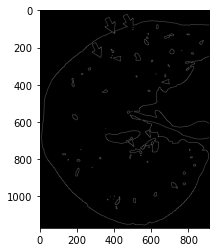

In [4]:
images = load_images_from_folder("./Ressources/test")
threshold_area_min = 200 # Réfléchir à l'utilisation d'un pourcentage de l'image ou utiliser des connaissances apriori de l'image 
threshold_max_point = 13
for image in images:  
    
    # Denoising the image
    image = cv2.GaussianBlur(image, (5, 5), 3)
    
    # Binarisation
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY) # Ne detecte que les flèches noires, il faut modifier le param 2 et 3 pour inverser cela et ajouter l'inverse de l'image
        
    # Contours Detection
    edged = cv2.Canny(binary,10,200) # Vérifier les paramètres entrés
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Get only extreme points of the contours
    
    # Sort the contours by area and then remove the largest frame contour
    n = len(contours)-1
    contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]
    num = 0
    for contour in contours:
        x,y,w,h = cv2.boundingRect(contour)
        hull = cv2.convexHull(contour)
        
        # ROI Extraction after area filtering
        area = cv2.contourArea(contour)
        nbr_points = len(points_poly(contour))
        
        if (area > threshold_area_min) & (nbr_points <13):
            print("Nombre de points du ROI n°",num)
            print(nbr_points)
            ROI = image[y:y+h, x:x+w]
            cv2.imwrite('./resultats/petitTest/ROI_{}.png'.format(num), ROI)
            num += 1
    cv2.drawContours(image,contour,-1,(0,255,0),1)
    plt.imshow(edged,cmap='gray')
            